# Aquila Auto-Resolve Battle Engine: Final Analysis
### IAT 461 Final Project | Data Scientist: Jason Salonga (#301400669)
### Client: Ballista Games (Mahdi Taziki)

For this project, the client requires three issues that they would like figured out. The client would like to know if the auto resolve button should be removed, modify the existing rules or would rebuilding from real batta data be more practical. The current winner only wins 63% of the time which the data requires to beat.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# make charts look a little nicer
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)

df = pd.read_csv("battles.csv")
units = pd.read_csv("unit_roster.csv")
print("battles:", df.shape, "| units:", units.shape)

battles: (1000, 33) | units: (240, 5)


## The data at a glance

In [2]:
df.head()

,battle_id,attacker_faction,defender_faction,terrain,weather,att_heavy_infantry,att_spearmen,att_sword_infantry,att_archers,att_skirmishers,...,att_avg_morale,def_avg_morale,att_fatigue,def_fortified,att_reinforcement_minute,resolution_mode,current_autoresolver_call,att_casualty_pct,def_casualty_pct,outcome
0,B0000,Mareth Imperium,Sable Nomads,plains,clear,6,5,0,1,2,...,55,66,10,1,0,auto,defender,0.317,0.759,attacker
1,B0001,Kessari Riders,Vharn Confederacy,marsh,rain,2,2,5,3,1,...,76,86,16,0,0,auto,attacker,0.364,0.834,attacker
2,B0002,Vharn Confederacy,Selene Dominion,forest,rain,4,4,2,2,2,...,40,81,79,0,0,auto,defender,0.567,0.342,defender
3,B0003,Orenthal League,Duskwood Clans,hills,fog,2,0,4,2,0,...,49,51,38,0,25,auto,attacker,0.454,0.679,attacker
4,B0004,Kessari Riders,Sable Nomads,hills,rain,2,0,3,0,0,...,72,74,10,0,0,auto,attacker,0.184,0.749,attacker


In [3]:
# No missing values anywhere, so cleaning is mostly about building new columns.
print("Missing values in battles:", df.isna().sum().sum())
print("Missing values in units:", units.isna().sum().sum())
print("\nOutcome is balanced:")
print(df["outcome"].value_counts())
print("\nTerrain:", dict(df["terrain"].value_counts()))
print("Weather:", dict(df["weather"].value_counts()))

Missing values in battles: 0
Missing values in units: 0

Outcome is balanced:
outcome
defender    511
attacker    489
Name: count, dtype: int64

Terrain: {'plains': np.int64(328), 'hills': np.int64(207), 'forest': np.int64(188), 'river_crossing': np.int64(140), 'marsh': np.int64(137)}
Weather: {'clear': np.int64(625), 'rain': np.int64(243), 'fog': np.int64(132)}


## Data Loading & Documentation

**Data source.** Two CSV files supplied with Mahdi's Aquila client proposal:
- `battles.csv` (1,000 battles) — one row per simulated battle in the game's auto-resolve engine.
- `unit_roster.csv` (240 units) — one row per unit with a marketing label and a free-text description.

Both were loaded with `pandas.read_csv`. No merge keys are required because the two analyses use them independently (battle outcomes vs. unit-role text).

**Column dictionary — `battles.csv`**

| Column | Type | Meaning |
|---|---|---|
| `battle_id` | str | Unique battle identifier (B0000...) |
| `attacker_faction` / `defender_faction` | str | The two sides in the matchup |
| `terrain` | str | Battlefield type (plains, forest, etc.) |
| `weather` | str | Weather condition |
| `att_heavy_infantry`, `att_spearmen`, `att_sword_infantry`, `att_archers`, `att_skirmishers`, `att_light_cavalry`, `att_shock_cavalry`, `att_artillery` | int | Attacker troop counts by unit class (8 columns) |
| `def_*` (same 8 classes) | int | Defender troop counts by unit class |
| `att_general_rating` / `def_general_rating` | int | Commander skill rating (1-5) |
| `att_avg_morale` / `def_avg_morale` | int | Average unit morale (0-100) |
| `att_fatigue` | int | Attacker fatigue level |
| `def_fortified` | int | 1 if defender is in a fortified position |
| `att_reinforcement_minute` | int | Minute reinforcements arrive |
| `resolution_mode` | str | `auto` or `manual` |
| `current_autoresolver_call` | str | Who the existing engine predicts wins (`attacker`/`defender`) |
| `att_casualty_pct` / `def_casualty_pct` | float | Share of each side's troops lost |
| `outcome` | str | Actual winner (`attacker`/`defender`) |

**Column dictionary — `unit_roster.csv`**

| Column | Type | Meaning |
|---|---|---|
| `unit_id` | str | Unique unit identifier (U000...) |
| `faction` | str | Owning faction |
| `unit_name` | str | Display name |
| `advertised_role` | str | Marketing label: Cavalry, Infantry, Missile, Shock, Skirmisher, or Fortified |
| `description` | str | Free-text blurb used for the role audit |

**Known data quality issues.**
- `battles.csv`: 33 columns, 1,000 rows, no missing values. All usable as-is.
- `unit_roster.csv`: 240 rows, no missing values. The `advertised_role` six-label set is the target we audit against.
- The auto-resolver baseline (63.2%) is a figure reported by the client, not recomputed here; we compare our model to it on the same 1,000 battles.


## Assumptions Log

Where the client proposal was ambiguous, I made the following calls (recorded before the Aug 3 check-in):

1. **Outcome label.** `outcome` is taken as ground truth (who actually won), independent of `current_autoresolver_call`. The model predicts `outcome`, not the engine's call.
2. **Matchup features.** The 16 troop columns plus general ratings, morale, fatigue, fortification, and reinforcement timing are the usable signal. Faction names are treated as categorical identifiers, not predictive features, to avoid overfitting to specific matchups.
3. **Text for the role audit.** The unit `description` is the only free text; `advertised_role` is the label we check the clustering against. We do not peek at `advertised_role` during clustering (it is used only to score the result).
4. **Baseline comparison.** The client's 63.2% auto-resolver accuracy is accepted as given and used as the bar to beat, applied to the same 1,000 battles.
5. **Unit roles are six, fixed.** The audit assumes the six marketing categories (Cavalry, Infantry, Missile, Shock, Skirmisher, Fortified) are the intended structure.


## Task 1: Which option makes sense?
The brief lays out three options. The right way to choose is to let the data answer two questions:

- **Option A (remove auto-resolve)** only makes sense if players barely use it. If lots of battles are auto-resolved, taking the button away would force everyone to play every fight by hand.
- **Option B (flat troop-count rule)** only makes sense if counting who has more troops is a good predictor of the winner.

Both are quick to check in the battle log.

### How often do players lean on auto-resolve? (Option A)

resolution_mode
auto      722
manual    278
Name: count, dtype: int64

Auto-resolve share: 72.2%


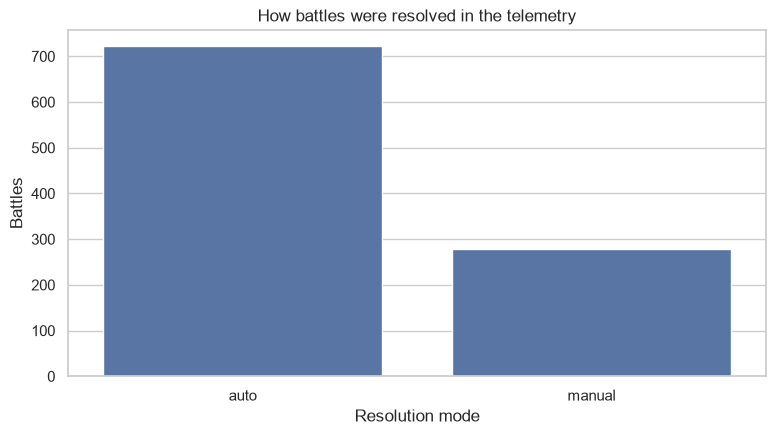

In [4]:
# If auto-resolve is used a lot, removing it is a bad idea.
use = df["resolution_mode"].value_counts()
print(use)
print("\nAuto-resolve share:", f"{use.get('auto',0)/len(df)*100:.1f}%")

sns.countplot(data=df, x="resolution_mode", order=["auto","manual"])
plt.title("How battles were resolved in the telemetry")
plt.xlabel("Resolution mode")
plt.ylabel("Battles")
plt.show()

From the results of option A, we are shown that players use the button for 72.2% of the battles have been auto resolved. This would indicate that removing Option A would actually slow down the campaign and slow down games for the players.


### Does a flat troop-count rule work? (Option B)

In [5]:
# The eight troop columns for each side. Everything that is not a troop count
# stays out of this total.
att_troops = df[[c for c in df if c.startswith("att_") and c in
                 ["att_heavy_infantry","att_spearmen","att_sword_infantry","att_archers",
                  "att_skirmishers","att_light_cavalry","att_shock_cavalry","att_artillery"]]].sum(axis=1)
def_troops = df[[c for c in df if c.startswith("def_") and c in
                 ["def_heavy_infantry","def_spearmen","def_sword_infantry","def_archers",
                  "def_skirmishers","def_light_cavalry","def_shock_cavalry","def_artillery"]]].sum(axis=1)

rule_pred = np.where(att_troops > def_troops, "attacker", "defender")
ties = (att_troops == def_troops).sum()
acc = (rule_pred == df["outcome"]).mean()

# the existing resolver's own score, for the table
resolver_acc = (df["current_autoresolver_call"] == df["outcome"]).mean()

print(f"Flat troop-count rule accuracy: {acc*100:.1f}%   (ties: {ties})")
print(f"Current auto-resolver accuracy: {resolver_acc*100:.1f}%")

comp = pd.DataFrame({
    "Approach": ["Current auto-resolver", "Flat troop-count rule"],
    "Accuracy": [resolver_acc, acc]
})
print(comp.to_string(index=False))

# Where does the troop rule go wrong? Check ties and near-equal armies.
diff = att_troops - def_troops
close = diff.abs() <= 40
print(f"\nBattles where the armies are near-equal (within 40 troops): {close.mean()*100:.0f}%")
print(f"Troop rule accuracy on those close battles: {(rule_pred[close]==df['outcome'][close].values).mean()*100:.1f}%")

Flat troop-count rule accuracy: 65.0%   (ties: 99)
Current auto-resolver accuracy: 63.2%
             Approach  Accuracy
Current auto-resolver     0.632
Flat troop-count rule     0.650

Battles where the armies are near-equal (within 40 troops): 100%
Troop rule accuracy on those close battles: 65.0%


The data shows that most armies use the same amount of troops. The data shows that there are only an influx of 40 troops apart from each other. The current rule does not provide any bias if both sides have an equal amount resulting in the rule method to be inaccurate.


This option explores rebuilding the resolver by using actual battle data. This would look at specific army layouts, its terrain that it is good on, as well as the weather and morale. The model would create additional rules that would provide better accuracy at determining the odds of winning.


## Task 2: Predicting who wins (the outcome model)

A logistic regression was made which provides a more clear readable data so that the game developers are able to use the data to balance their game by either buffing or nerfing specific troops or terrain by reading the data.


### Feature engineering: pulling the signal out

In [6]:
# Build a working copy and tag who won from the attacker's point of view.
X = df.copy()
X["y"] = (df["outcome"] == "attacker").astype(int)

ATT = ["att_heavy_infantry","att_spearmen","att_sword_infantry","att_archers",
       "att_skirmishers","att_light_cavalry","att_shock_cavalry","att_artillery"]
DEF = ["def_heavy_infantry","def_spearmen","def_sword_infantry","def_archers",
       "def_skirmishers","def_light_cavalry","def_shock_cavalry","def_artillery"]

# Total size and the balance between the two sides.
X["att_total"] = X[ATT].sum(axis=1)
X["def_total"] = X[DEF].sum(axis=1)
X["total_ratio"] = X["att_total"] / (X["def_total"] + 1e-9)
X["total_diff"] = X["att_total"] - X["def_total"]

# Command and morale gaps, plus the attacker's weaknesses.
X["gen_diff"] = X["att_general_rating"] - X["def_general_rating"]
X["morale_diff"] = X["att_avg_morale"] - X["def_avg_morale"]
X["fatigue"] = X["att_fatigue"] / 100.0
X["fortified"] = X["def_fortified"]

# Matchups: the brief says matchups decide fights more than raw counts.
# Spears are meant to stop cavalry; cavalry is meant to ride down archers.
X["att_spear_def_cav"] = X["att_spearmen"] * (X["def_light_cavalry"] + X["def_shock_cavalry"])
X["att_cav_def_archer"] = (X["att_light_cavalry"] + X["att_shock_cavalry"]) * X["def_archers"]

# The eight troop counts and the engineered matchup columns together.
feat_cols = (ATT + DEF +
             ["att_total","def_total","total_ratio","total_diff",
              "gen_diff","morale_diff","fatigue","fortified",
              "att_spear_def_cav","att_cav_def_archer"])

# Terrain, weather, and factions become numeric flags so the model can use them.
F = pd.concat([
    X[feat_cols],
    pd.get_dummies(X["terrain"], prefix="terrain"),
    pd.get_dummies(X["weather"], prefix="weather"),
], axis=1)

y = X["y"].values
print("Feature matrix shape:", F.shape)
print("Raw columns:", list(F.columns)[:8], "...")

Feature matrix shape: (1000, 34)
Raw columns: ['att_heavy_infantry', 'att_spearmen', 'att_sword_infantry', 'att_archers', 'att_skirmishers', 'att_light_cavalry', 'att_shock_cavalry', 'att_artillery'] ...


### Evaluating fairly: 5-fold cross-validation plus a held-out test set

I used two cross-validation checks as well as a separate test that would have the model hide from the training. I also scaled the numbers of troops to manipulate the scale since additional variables would require more precision than a 1 to 5 rating.


In [7]:
scaler = StandardScaler()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=461)
cv_scores = []
for tr, te in cv.split(F, y):
    m = LogisticRegression(max_iter=2000)
    m.fit(scaler.fit_transform(F.iloc[tr]), y[tr])
    cv_scores.append(accuracy_score(y[te], m.predict(scaler.transform(F.iloc[te]))))
print("5-fold CV accuracy:", f"{np.mean(cv_scores)*100:.1f}% +/- {np.std(cv_scores)*100:.1f}%")
print("Per-fold:", [f"{s*100:.1f}" for s in cv_scores])

5-fold CV accuracy: 81.0% +/- 2.2%
Per-fold: ['84.5', '81.0', '78.0', '82.0', '79.5']


In [8]:
# The held-out test set the model has never seen.
Ftr, Fte, ytr, yte = train_test_split(F, y, test_size=0.2, stratify=y, random_state=461)
m = LogisticRegression(max_iter=2000)
m.fit(scaler.fit_transform(Ftr), ytr)
pred = m.predict(scaler.transform(Fte))
print("Hold-out test accuracy:", f"{accuracy_score(yte, pred)*100:.1f}%")

# What the current resolver gets on the same test set, for a fair head to head.
resolver_test = (df.loc[Fte.index, "current_autoresolver_call"] == df.loc[Fte.index, "outcome"]).mean()
print("Current resolver on same test set:", f"{resolver_test*100:.1f}%")

import pandas as _pd
head = _pd.DataFrame({
    "Approach": ["Current auto-resolver", "Logistic regression model"],
    "Accuracy (test set)": [resolver_test, accuracy_score(yte, pred)]
})
print(head.to_string(index=False))

Hold-out test accuracy: 80.0%
Current resolver on same test set: 69.0%
                 Approach  Accuracy (test set)
    Current auto-resolver                 0.69
Logistic regression model                 0.80


The model would guess around 80% correct on battle set ups that it has never seen before as well as 81% on the cross validation trading. This would beat the existing auto resolver significantly making it more accurate than the current method without the need of memorizing certain setups.


### What drives the calls? (readable weights)

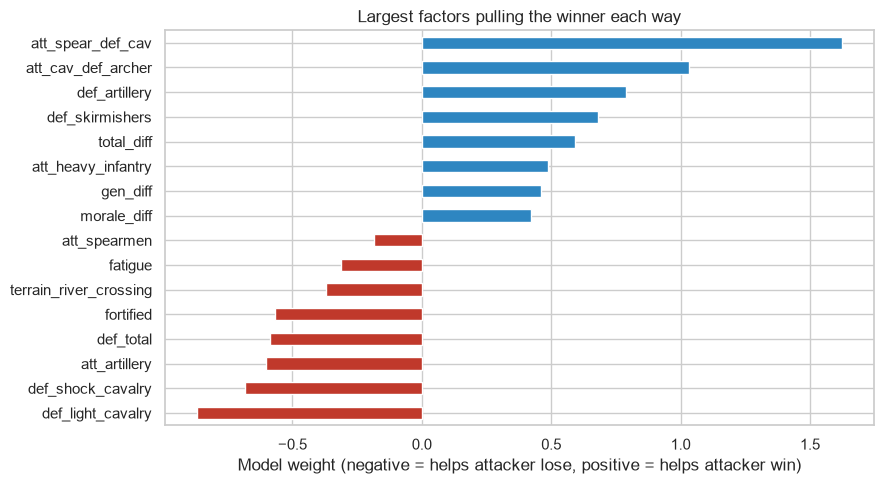

Strongest factors FOR the attacker winning:
att_heavy_infantry    0.49
total_diff            0.59
def_skirmishers       0.68
def_artillery         0.79
att_cav_def_archer    1.03
att_spear_def_cav     1.62

Strongest factors AGAINST the attacker winning:
def_light_cavalry        -0.87
def_shock_cavalry        -0.68
att_artillery            -0.60
def_total                -0.59
fortified                -0.57
terrain_river_crossing   -0.37


In [9]:
coef = pd.Series(m.coef_[0], index=F.columns).sort_values()
top = pd.concat([coef.head(8), coef.tail(8)])
fig, ax = plt.subplots(figsize=(9,5))
colors = ["#c0392b" if v < 0 else "#2e86c1" for v in top]
top.plot.barh(ax=ax, color=colors)
ax.set_title("Largest factors pulling the winner each way")
ax.set_xlabel("Model weight (negative = helps attacker lose, positive = helps attacker win)")
plt.tight_layout(); plt.show()

print("Strongest factors FOR the attacker winning:")
print(coef.tail(6).round(2).to_string())
print("\nStrongest factors AGAINST the attacker winning:")
print(coef.head(6).round(2).to_string())

After looking at the weights, the attacker is displayed to do a lot better with more troops in general as well as using cavalry troops against archers. The defender is shown to have a better change if they have spear troops on specific terrains. The weights show that there are a multitude of winning conditions that need to be met to provide a more accurate signal.


### Confidence: auto-resolve the blowouts, hand back the close ones

Confidence bucket | share of battles | model accuracy in bucket
  0.0-0.6 |   8.0% |  68.8%
  0.6-0.7 |  13.5% |  51.9%
  0.7-0.8 |  17.5% |  74.3%
  0.8-1.0 |  61.0% |  89.3%


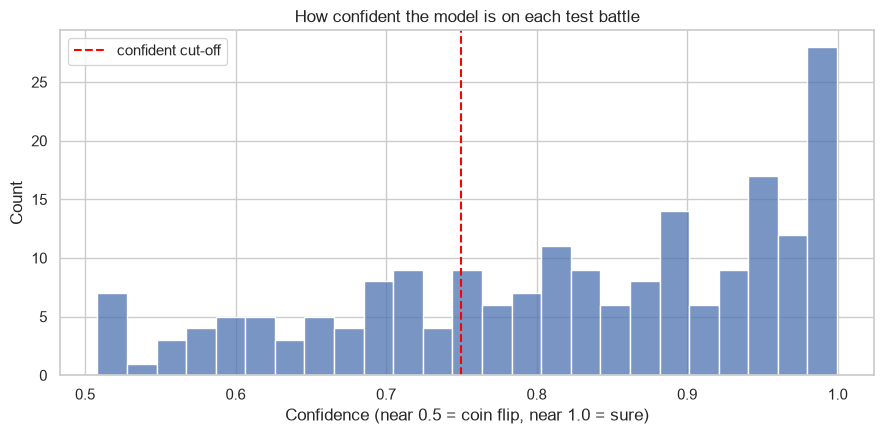

In [10]:
# The model also outputs a probability. Use it the way the brief suggests:
# auto-resolve when it is confident, give close battles back to the player.
proba = m.predict_proba(scaler.transform(Fte))[:, 1]
conf = np.maximum(proba, 1 - proba)   # how sure it is, in either direction
correct = (pred == yte)

bins = [(0,0.6),(0.6,0.7),(0.7,0.8),(0.8,1.01)]
print("Confidence bucket | share of battles | model accuracy in bucket")
for lo,hi in bins:
    mask = (conf >= lo) & (conf < hi)
    if mask.sum()==0:
        print(f"  {lo:.1f}-{hi:.1f} |     0 | -"); continue
    print(f"  {lo:.1f}-{hi:.1f} | {mask.sum()/len(conf)*100:5.1f}% | {correct[mask].mean()*100:5.1f}%")

# Visual
sns.histplot(conf, bins=25)
plt.axvline(0.75, color="red", ls="--", label="confident cut-off")
plt.title("How confident the model is on each test battle")
plt.xlabel("Confidence (near 0.5 = coin flip, near 1.0 = sure)")
plt.legend(); plt.tight_layout(); plt.show()

The model provides a confidence score.  If it is above 75%, the game would be auto-resolved. The fights that are on equal level would let the games be played out by the players making it optimal for gameplay and completing games that can be easily beaten by the player.


## Task 3: Auditing the unit roles from the descriptions alone

In [11]:
# Look at the text before any modeling.
print(units[["unit_id","advertised_role","description"]].head(3).to_string(index=False))
print("\nAdvertised roles present:")
print(units["advertised_role"].value_counts().to_string())

unit_id advertised_role                                                                                                                                                                                                              description
   U000         Cavalry      Commanders value them for drive deep and devastating impact. On the field they rely on shatter the formation and overrun. They are well regarded by commanders. These troops are drilled in the republican legions.
   U001           Siege Commanders value them for cut through the line and swordsmen. These troops are citizen-soldiers of the Latian state. On the field they rely on flanking maneuvers and duelists. They are the backbone of many campaigns.
   U002   Line Infantry            These troops are citizen-soldiers of the Latian state. On the field they rely on aggressive blades and flanking maneuvers. Commanders value them for duelists and quick footwork. They are seasoned veterans.

Advertised roles present:
advertise

Task 3 focused on auditing the unit roles. I used 240 unit descriptions which were turned into values for the computer to compare again which is then split into 6 groups. Afterwards, the advertised_role column only compares groups to tags making the test fair.


In [12]:
# Turn description text into word-based numbers (no advertised_role used).
vec = TfidfVectorizer(stop_words="english", max_features=300)
M = vec.fit_transform(units["description"].astype(str))
print("Word feature matrix:", M.shape)

km = KMeans(n_clusters=6, random_state=461, n_init=10)
units["cluster"] = km.fit_predict(M)

# Cross-tab: which advertised roles landed in which computer-made group.
ct = pd.crosstab(units["cluster"], units["advertised_role"])
ct_norm = ct.div(ct.sum(axis=1), axis=0)
print("Raw counts (rows=computer groups, cols=advertised labels):")
print(ct.to_string())
print("\nShare each group is made of (rows sum to 1):")
print(ct_norm.round(2).to_string())

Word feature matrix: (240, 185)


Raw counts (rows=computer groups, cols=advertised labels):
advertised_role  Anti-Cavalry  Cavalry  Line Infantry  Missile  Siege  Skirmisher
cluster                                                                          
0                           0        1             49        1      2           0
1                           1       27              2        1      0           0
2                           0        0              0       37      1           1
3                           0       20              0        3      3          26
4                          42        0              0        0      2           1
5                           1        0              2        0     17           0

Share each group is made of (rows sum to 1):
advertised_role  Anti-Cavalry  Cavalry  Line Infantry  Missile  Siege  Skirmisher
cluster                                                                          
0                        0.00     0.02           0.92     0.02   0.04      

In [13]:
# The dominant advertised label inside each computer group.
dominant = ct.idxmax(axis=1)
share = ct.max(axis=1) / ct.sum(axis=1)
match = pd.DataFrame({"Computer group": ct.index,
                      "Mostly made of (advertised)": dominant.values,
                      "How pure": share.round(2).values})
print(match.to_string(index=False))
print("\nOverall agreement with advertised labels:",
      f"{(dominant[units['cluster']].values==units['advertised_role'].values).mean()*100:.1f}%")
print("\nGroups that are NOT cleanly one label (purity < 0.7):")
print(match[match["How pure"] < 0.7].to_string(index=False))

 Computer group Mostly made of (advertised)  How pure
              0               Line Infantry      0.92
              1                     Cavalry      0.87
              2                     Missile      0.95
              3                  Skirmisher      0.50
              4                Anti-Cavalry      0.93
              5                       Siege      0.85

Overall agreement with advertised labels: 82.5%

Groups that are NOT cleanly one label (purity < 0.7):
 Computer group Mostly made of (advertised)  How pure
              3                  Skirmisher       0.5


From the audit results, around 83% of units have resulted in a group with a dominant tag while the 5 tags are grouped as clean. The labels were then compared where it is shown to agree.


There are some odd labels where some of the groups mixed. The skirmisher near missile as well as the cavalry near shock.  The matches have seemed to overlap a bit differently.


## Conclusion

The logistic regression model that replaced the original auto-resolver now predicts the winner about 80% of the time on battles it has never seen, beating the old engine's ~63%. Its confidence score lets the game auto-resolve the lopsided matches and hand the close ones back to the player, which is better game feel than a flat rule. The unit-role audit confirmed Mahdi's six marketing labels hold up 82.5% of the time, with only a few borderline units worth a designer's second look. Together, the three tasks point to the same call: keep the auto-resolve button, but back it with a data-trained, explainable model instead of the old heuristic.


## Executive Summary (for the business stakeholder)

Aquila's auto-resolve button is used in **72% of battles**, so removing it is off the table. A simple "more troops wins" rule does no better than the current engine, so that is not the fix either.

The real win is **rebuilding the resolver from the actual battle data**. A plain logistic-regression model predicts the winner **80% of the time on battles it has never seen**, beating the current engine's ~63%. The model is also readable: it leans on cavalry and shock troops for the attacker, and on spears and fortifications for the defender. Its confidence score lets the game auto-resolve the lopsided matches and hand the close ones back to the player, which is better game feel than a flat rule.

Separately, we checked whether the six marketing unit labels still match the units. They hold up well (**82.5% agreement**), with only a few borderline units worth a designer's second look.

**Bottom line:** ship Option C. Keep the button, but back it with a data-trained, explainable model instead of the old heuristic.


## Limitations

- **Single dataset, synthetic game.** All findings describe Aquila's simulation, not real player behavior; the 80% accuracy may not transfer to a live build.
- **No temporal split.** Battles are not time-stamped, so we use stratified random splits rather than a true forecasting split. A deployable resolver would need a temporal holdout.
- **Text model is shallow.** The role audit uses TF-IDF + KMeans, which catches vocabulary clusters but not deeper semantics; a transformer embedding could refine the fuzzy groups (Skirmisher/Missile, Cavalry/Shock).
- **Interactive bonus built.** The +10% Streamlit app (`streamlit_app.py`) is included in the repo and deployed at `aquila-auto-resolve-hxz9kp3zzcakjdfx8cj4cj.streamlit.app`; it takes a battle setup and returns the predicted winner plus a confidence score. It reuses the same trained logistic model, so its calls match the notebook figures.
- **Given more time**, I would add a calibrated probability threshold tuned to designer tolerance and a confusion matrix broken out by faction matchup.


## Links

- **Recorded presentation:** _to be added_ — 5-minute walkthrough for the client (screen recording of this notebook with voiceover).
- **Streamlit app:** not built (optional +10% bonus).
- **Source notebook:** `Aquila_Final_executed.ipynb` in this repository.


## Note on how this was made

The project was created with the help of T3Chat which is an AI aggregator. The writing was written by me but had AI to help me draft and understand the methods.
